# Projet 1 : Analyse d'une enquête de marché
## Vente de plats jetables

**Contexte** : Une entreprise locale souhaite lancer une activité de vente de plats jetables. Une enquête de terrain a été réalisée auprès de clients potentiels. Ce notebook présente l'analyse complète des résultats.

**Objectifs** :
- Nettoyer et préparer les données d'enquête
- Analyser les préférences et comportements des clients
- Identifier les facteurs qui influencent l'intention d'achat
- Formuler des recommandations pour l'entreprise

---
## 1. Importation des bibliothèques

In [1]:
# Installation de openpyxl
!pip install openpyxl -q

In [2]:
# Les bibliothèques dont on a besoin
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pour la segmentation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

# Configuration des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Afficher toutes les colonnes dans les dataframes
pd.set_option('display.max_columns', None)

# Ignorer les warnings pour garder un affichage propre
import warnings
warnings.filterwarnings('ignore')


---
## 2. Chargement et exploration des données

On commence par charger le fichier Excel et voir à quoi ressemblent nos données.

In [3]:
# Si tu es sur Colab, décommente ces lignes pour uploader le fichier
from google.colab import files
uploaded = files.upload()

# Chargement du fichier
df = pd.read_excel('enquête.xlsx')

# Voyons ce qu'on a
print(f"Notre fichier contient {df.shape[0]} réponses et {df.shape[1]} questions.")

Saving enquête.xlsx to enquête (1).xlsx
Notre fichier contient 123 réponses et 29 questions.


In [4]:
# Un aperçu des premières lignes
df.head()

,Code de l'agent recenseur,Date du Recencement,Que vendez-vous principalement ?,Utilisez vous des emballages alimentaires ( plats à jeter) ?,Combien d' emballages alimentaires à jeter utilisez-vous en moyenne par jour ?,Quels sont les principaux objectifs que vous recherchez avec les emballages alimentaires utilisés?,Préférez-vous des emballages alimentaires jetables ou réutilisables pour votre établissement ?,"À quelle fréquence aimeriez-vous recevoir des livraisons d'emballages alimentaires (quotidiennement, hebdomadairement, mensuellement, etc.) ?","Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [1]","Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [2]",Quel est votre budget approximatif pour les emballages alimentaires par mois ?,"Comment préférez-vous être approvisionné en emballages alimentaires (commande en ligne, distribution locale, etc.) ?","Quels types de matériaux d'emballage privilégiez-vous (plastique, carton, bioplastiques, etc.) ?","Avez-vous des besoins spécifiques en termes de tailles d'emballages (petit, moyen, grand, etc.) ?",Vous voulez des emballages alimentaires avec combien de compartilment,Préférez-vous des emballages avec des fenêtres transparentes pour montrer les produits ?,Pouvez vous nous montrerles emballages que vous avez déjà?,Quelle contenance préférez-vous? [1 Compartiment],Quelle contenance préférez-vous? [2 Compartiments],Quelle contenance préférez-vous? [3 Compartiments],Quelle contenance préférez-vous? [4 Compartiments],Lequel des echantillons préférez-vous,Acheteriez vous ces plats si on vous en apporte ?,A combien vous reviens la centaine des plats que vous utiliser actuellement?,Allez-vous acheter nos emballages alimentaires meme si cela coute légèrement plus cher que ce que vous utilisez en ce moment ?,Y a-t-il des contraintes légales ou normatives concernant les emballages alimentaires que vous devez respecter ?,Quels autres critères sont importants pour vous lors du choix de vos emballages alimentaires ?,Avez-vous d'autres commentaires ou besoins spécifiques que vous aimeriez partager avec nous ?,Avez-vous des suggestions pour l'entreprise qui veut commercialiser les plats jetables?
0,AG-CAL-001,2024-11-18,"Akassa+Monyo, Côme+ Monyo, Riz",Oui,Entre 1 et 10,Experience Client,Les deux,Mensuellement,Résistance à la chaleur,Securité alimentaire,5000f,Distribution locale,"Carton, Bioplastiques",Moyen,"1 seul compartiment, 2 compartiments",Oui,https://drive.google.com/open?id=1tI6HLFXYQUZq...,700ML,700ML,Autres,Autres,Option 4,Oui,2.500f,Non,Non,Fermeture hermétique,Non,NaN
1,AG-CAL-001,2024-11-18,"Riz gras, pâte rouge",Oui,Entre 1 et 30,Experience Client,Jetable,Mensuellement,Facilité d'ouverture,Résistance à la chaleur,NaN,Distribution locale,"Plastique, Bioplastiques",Grand et surtout creux,1 seul compartiment,Non,https://drive.google.com/open?id=1549pys82H0F3...,850ML,800ML,800ML,Autres,Un seul compartiment en Papier carton dur,Oui,5.000f,Peut-être,Non,RAS,Nous espérons que vos assiettes lors de la com...,NaN
2,AG-CAL-001,2024-11-18,Akassa+viande de porc,Oui,Entre 1 et 30,Experience Client,Jetable,Hebdomadairement,Securité alimentaire,Résistance à la chaleur,10.000f,Distribution locale,"Carton, Bioplastiques",Moyen,2 compartiments,Non,https://drive.google.com/open?id=1xddFhSIN0_w4...,500ML,500ML,500ML,500ML,Multi-compartiment en Papier carton dur,Oui,5.000f,Peut-être,Non,RAS,Non,NaN
3,AG-CAL-001,2024-11-19,Mets Africains - Mets Européens,Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Jetable,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,15.000f,Commande en ligne,"Carton, Bioplastiques",Moyen,"1 seul compartiment, 2 compartiments",Oui,https://drive.google.com/open?id=1czuEGSIvain1...,850ML,850ML,1100ML,1100ML,"Multi-c

In [5]:
# Liste de toutes les colonnes (questions de l'enquête)
print("Les questions de l'enquête :\n")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Les questions de l'enquête :

1. Code de l'agent recenseur
2. Date du Recencement
3. Que vendez-vous principalement ?
4. Utilisez vous des  emballages alimentaires ( plats à jeter) ?
5. Combien d' emballages alimentaires  à jeter utilisez-vous en moyenne par jour ?
6. Quels sont les principaux objectifs que vous recherchez avec les  emballages alimentaires  utilisés? 
7. Préférez-vous des emballages alimentaires jetables ou réutilisables pour votre établissement ?
8. À quelle fréquence aimeriez-vous recevoir des livraisons d'emballages alimentaires (quotidiennement, hebdomadairement, mensuellement, etc.) ?
9. Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [1]
10. Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [2]
11. Quel est votre budget approximatif pour

### Description des variables

On a 29 colonnes qui couvrent :
- **Informations générales** : code agent, date
- **Activité du répondant** : type de vente
- **Utilisation actuelle** : quantité d'emballages, objectifs recherchés
- **Préférences** : taille, compartiments, contenance, matériaux, design
- **Prix** : budget, disposition à payer plus
- **Intention d'achat** : achat potentiel
- **Logistique** : fréquence de livraison, mode d'approvisionnement

In [6]:
# Types de données et valeurs non-nulles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 29 columns):
 #   Column                                                                                                                                                                   Non-Null Count  Dtype         
---  ------                                                                                                                                                                   --------------  -----         
 0   Code de l'agent recenseur                                                                                                                                                123 non-null    object        
 1   Date du Recencement                                                                                                                                                      123 non-null    datetime64[ns]
 2   Que vendez-vous principalement ?                                      

On remarque que presque toutes les colonnes sont de type "object" (texte), sauf la date. C'est normal pour un questionnaire avec des réponses à choix multiples.

---
## 3. Préparation des données

Avant d'analyser, il faut nettoyer les données : traiter les valeurs manquantes, corriger les incohérences et harmoniser les réponses.

### 3.1 Identification des valeurs manquantes

In [7]:
# Comptons les valeurs manquantes
manquantes = df.isnull().sum()
pct_manquantes = (manquantes / len(df) * 100).round(2)

# Créons un tableau récapitulatif
recap_manquantes = pd.DataFrame({
    'Nb manquantes': manquantes,
    'Pourcentage': pct_manquantes
})

# On affiche seulement les colonnes avec des valeurs manquantes
recap_manquantes[recap_manquantes['Nb manquantes'] > 0].sort_values('Nb manquantes', ascending=False)

,Nb manquantes,Pourcentage
Avez-vous des suggestions pour l'entreprise qui veut commercialiser les plats jetables?,44,35.77
Quelle contenance préférez-vous? [4 Compartiments],43,34.96
Quelle contenance préférez-vous? [3 Compartiments],36,29.27
Pouvez vous nous montrerles emballages que vous avez déjà?,29,23.58
Quel est votre budget approximatif pour les emballages alimentaires par mois ?,12,9.76
A combien vous reviens la centaine des plats que vous utiliser actuellement?,7,5.69
Quelle contenance préférez-vous? [1 Compartiment],4,3.25
Quelle contenance préférez-vous? [2 Compartiments],3,2.44


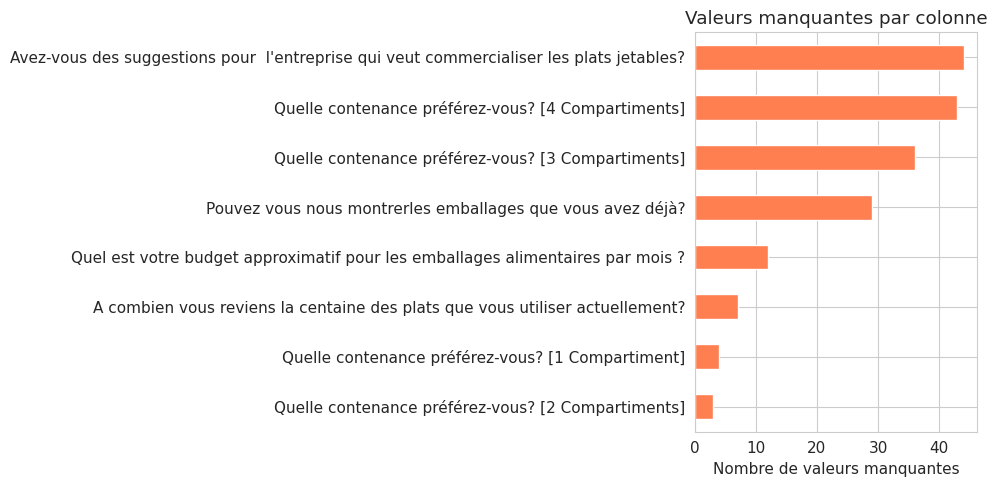

In [8]:
# Visualisation des valeurs manquantes
cols_manquantes = manquantes[manquantes > 0].sort_values(ascending=True)

plt.figure(figsize=(10, 5))
cols_manquantes.plot(kind='barh', color='coral')
plt.title('Valeurs manquantes par colonne')
plt.xlabel('Nombre de valeurs manquantes')
plt.tight_layout()
plt.show()

**Interprétation** :
- Les colonnes sur les contenances à 3 et 4 compartiments ont beaucoup de valeurs manquantes (~30-35%), ce qui est logique car tout le monde ne veut pas ces options
- La colonne "suggestions" a aussi beaucoup de vides, c'est normal pour une question ouverte
- Le budget a 9.76% de non-réponses, certains ne voulaient peut-être pas donner cette info

### 3.2 Nettoyage et harmonisation

In [9]:
# On fait une copie pour garder l'original intact
df_clean = df.copy()

# Nettoyage des espaces en début et fin de texte
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    # Les 'nan' en texte deviennent de vrais NaN
    df_clean[col] = df_clean[col].replace('nan', np.nan)

print("Espaces nettoyés !")

Espaces nettoyés !


In [10]:
# Harmonisation : tout en minuscules pour éviter les doublons du genre "Oui" vs "oui"
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.lower()

print("Tout est maintenant en minuscules.")

Tout est maintenant en minuscules.


In [11]:
# Traitement des valeurs manquantes
# Pour les colonnes texte, on met "non renseigné"
# Pour les colonnes numériques, on utiliserait la médiane (mais on n'en a pas ici)

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col] = df_clean[col].fillna('non renseigné')
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")

Valeurs manquantes restantes : 0


In [12]:
# Vérifions le résultat
df_clean.head()

,Code de l'agent recenseur,Date du Recencement,Que vendez-vous principalement ?,Utilisez vous des emballages alimentaires ( plats à jeter) ?,Combien d' emballages alimentaires à jeter utilisez-vous en moyenne par jour ?,Quels sont les principaux objectifs que vous recherchez avec les emballages alimentaires utilisés?,Préférez-vous des emballages alimentaires jetables ou réutilisables pour votre établissement ?,"À quelle fréquence aimeriez-vous recevoir des livraisons d'emballages alimentaires (quotidiennement, hebdomadairement, mensuellement, etc.) ?","Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [1]","Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [2]",Quel est votre budget approximatif pour les emballages alimentaires par mois ?,"Comment préférez-vous être approvisionné en emballages alimentaires (commande en ligne, distribution locale, etc.) ?","Quels types de matériaux d'emballage privilégiez-vous (plastique, carton, bioplastiques, etc.) ?","Avez-vous des besoins spécifiques en termes de tailles d'emballages (petit, moyen, grand, etc.) ?",Vous voulez des emballages alimentaires avec combien de compartilment,Préférez-vous des emballages avec des fenêtres transparentes pour montrer les produits ?,Pouvez vous nous montrerles emballages que vous avez déjà?,Quelle contenance préférez-vous? [1 Compartiment],Quelle contenance préférez-vous? [2 Compartiments],Quelle contenance préférez-vous? [3 Compartiments],Quelle contenance préférez-vous? [4 Compartiments],Lequel des echantillons préférez-vous,Acheteriez vous ces plats si on vous en apporte ?,A combien vous reviens la centaine des plats que vous utiliser actuellement?,Allez-vous acheter nos emballages alimentaires meme si cela coute légèrement plus cher que ce que vous utilisez en ce moment ?,Y a-t-il des contraintes légales ou normatives concernant les emballages alimentaires que vous devez respecter ?,Quels autres critères sont importants pour vous lors du choix de vos emballages alimentaires ?,Avez-vous d'autres commentaires ou besoins spécifiques que vous aimeriez partager avec nous ?,Avez-vous des suggestions pour l'entreprise qui veut commercialiser les plats jetables?
0,ag-cal-001,2024-11-18,"akassa+monyo, côme+ monyo, riz",oui,entre 1 et 10,experience client,les deux,mensuellement,résistance à la chaleur,securité alimentaire,5000f,distribution locale,"carton, bioplastiques",moyen,"1 seul compartiment, 2 compartiments",oui,https://drive.google.com/open?id=1ti6hlfxyquzq...,700ml,700ml,autres,autres,option 4,oui,2.500f,non,non,fermeture hermétique,non,non renseigné
1,ag-cal-001,2024-11-18,"riz gras, pâte rouge",oui,entre 1 et 30,experience client,jetable,mensuellement,facilité d'ouverture,résistance à la chaleur,non renseigné,distribution locale,"plastique, bioplastiques",grand et surtout creux,1 seul compartiment,non,https://drive.google.com/open?id=1549pys82h0f3...,850ml,800ml,800ml,autres,un seul compartiment en papier carton dur,oui,5.000f,peut-être,non,ras,nous espérons que vos assiettes lors de la com...,non renseigné
2,ag-cal-001,2024-11-18,akassa+viande de porc,oui,entre 1 et 30,experience client,jetable,hebdomadairement,securité alimentaire,résistance à la chaleur,10.000f,distribution locale,"carton, bioplastiques",moyen,2 compartiments,non,https://drive.google.com/open?id=1xddfhsin0_w4...,500ml,500ml,500ml,500ml,multi-compartiment en papier carton dur,oui,5.000f,peut-être,non,ras,non,non renseigné
3,ag-cal-001,2024-11-19,mets africains - mets européens,oui,entre 15 et 30,"experience client, marketing durable, innovati...",jetable,hebdomadairement,résistance à la chaleur,securité alimentaire,15.000f,commande en ligne,"carton, bioplastiques",moyen,"1 seul compartiment, 2 compartiments",oui,https://drive.google.com/open?id=1czuegsivai

**Résumé du nettoyage effectué** :
- Suppression des espaces inutiles
- Harmonisation en minuscules
- Remplacement des valeurs manquantes par "non renseigné"

Les données sont maintenant prêtes pour l'analyse.

---
## 4. Analyse exploratoire

On va maintenant explorer les données pour comprendre qui sont nos répondants et ce qu'ils veulent.

### 4.1 Types d'activités des répondants

Qui a répondu à notre enquête ? Quels types de vendeurs ?

In [13]:
# La colonne qui nous intéresse
col_activite = 'Que vendez-vous principalement ?'

# Distribution des activités
print("Types d'activités des répondants :\n")
print(df_clean[col_activite].value_counts().head(15))

Types d'activités des répondants :

Que vendez-vous principalement ?
mets africains et européens                     19
mets européens et africains                      8
mets africains                                   8
fast food                                        6
met africains et européens                       3
met africains et européennes                     2
mets africains et européennes                    2
akassa+viande de porc                            1
piron+viande, télibo+ légumes, akassa+ monyo     1
riz, akassa,  fast food, grillade                1
riz, akassa                                      1
mets africains - mets européens                  1
riz, piron + viande, shawarma...                 1
riz créole, piron, spaghetti, couscous           1
riz blanc+sauce, salade                          1
Name: count, dtype: int64


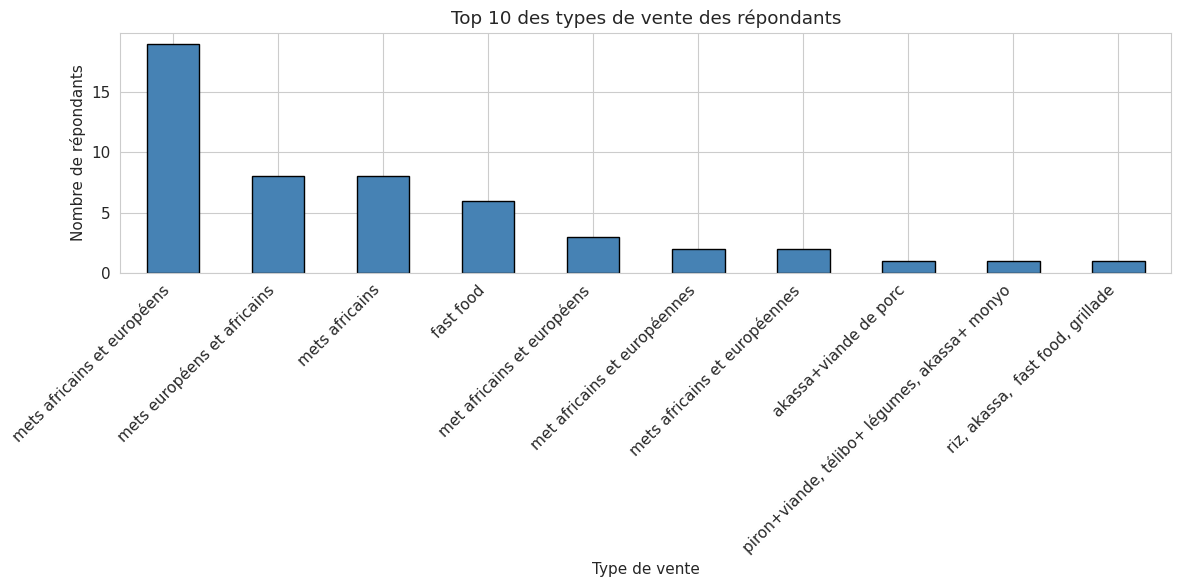

In [14]:
# Graphique - on prend le top 10 pour que ce soit lisible
plt.figure(figsize=(12, 6))
df_clean[col_activite].value_counts().head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 des types de vente des répondants')
plt.xlabel('Type de vente')
plt.ylabel('Nombre de répondants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interprétation** :
- La majorité des répondants vendent des "mets africains et européens" (19 personnes, soit 15.4%)
- On trouve aussi des vendeurs de fast-food, de mets africains seuls, etc.
- Il y a une grande diversité d'activités (82 types différents), ce qui montre que l'enquête a touché des profils variés
- Cette diversité est positive car elle nous donne une vision large du marché

### 4.2 Utilisation actuelle des plats jetables

In [15]:
# Est-ce qu'ils utilisent déjà des emballages ?
col_utilisation = 'Utilisez vous des  emballages alimentaires ( plats à jeter) ?'
print("Utilisation actuelle d'emballages :")
print(df_clean[col_utilisation].value_counts())

Utilisation actuelle d'emballages :
Utilisez vous des  emballages alimentaires ( plats à jeter) ?
oui    123
Name: count, dtype: int64


**100% des répondants utilisent déjà des emballages alimentaires.** C'est une très bonne nouvelle : on s'adresse à des clients qui connaissent déjà le produit et ont un besoin réel.

In [16]:
# Quelle quantité par jour ?
col_quantite = "Combien d' emballages alimentaires  à jeter utilisez-vous en moyenne par jour ?"

print("Quantité d'emballages utilisés par jour :\n")
print(df_clean[col_quantite].value_counts())

Quantité d'emballages utilisés par jour :

Combien d' emballages alimentaires  à jeter utilisez-vous en moyenne par jour ?
entre 1-15        55
entre 15 et 30    39
entre 30 et 50    17
entre 1 et 30      8
entre 1 et 10      4
Name: count, dtype: int64


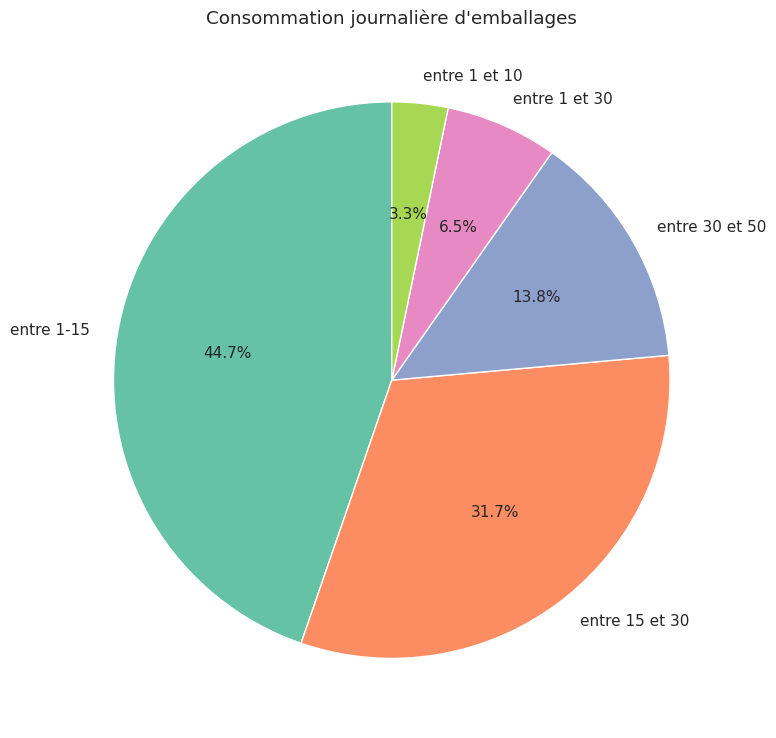

In [17]:
# Graphique en camembert
plt.figure(figsize=(8, 8))
df_clean[col_quantite].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2')
)
plt.title('Consommation journalière d\'emballages')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interprétation** :
- **44.7%** utilisent entre 1 et 15 emballages/jour → petits établissements
- **31.7%** utilisent entre 15 et 30 emballages/jour → établissements moyens
- **13.8%** utilisent entre 30 et 50 emballages/jour → gros consommateurs

La demande est donc réelle et régulière. Un client moyen consomme environ 15-30 emballages par jour.

In [18]:
# Quels objectifs recherchent-ils avec leurs emballages ?
col_objectifs = 'Quels sont les principaux objectifs que vous recherchez avec les  emballages alimentaires  utilisés? '

print("Objectifs recherchés :\n")
print(df_clean[col_objectifs].value_counts())

Objectifs recherchés :

Quels sont les principaux objectifs que vous recherchez avec les  emballages alimentaires  utilisés? 
economie de couts, marketing durable                          50
economie de couts                                             27
economie de couts, experience client, marketing durable       13
experience client                                              9
marketing durable, innovation culinaire                        7
economie de couts, experience client                           4
economie de couts, marketing durable, innovation culinaire     4
experience client, marketing durable, innovation culinaire     3
marketing durable                                              3
experience client, innovation culinaire                        1
experience client, marketing durable                           1
economie de couts, innovation culinaire                        1
Name: count, dtype: int64


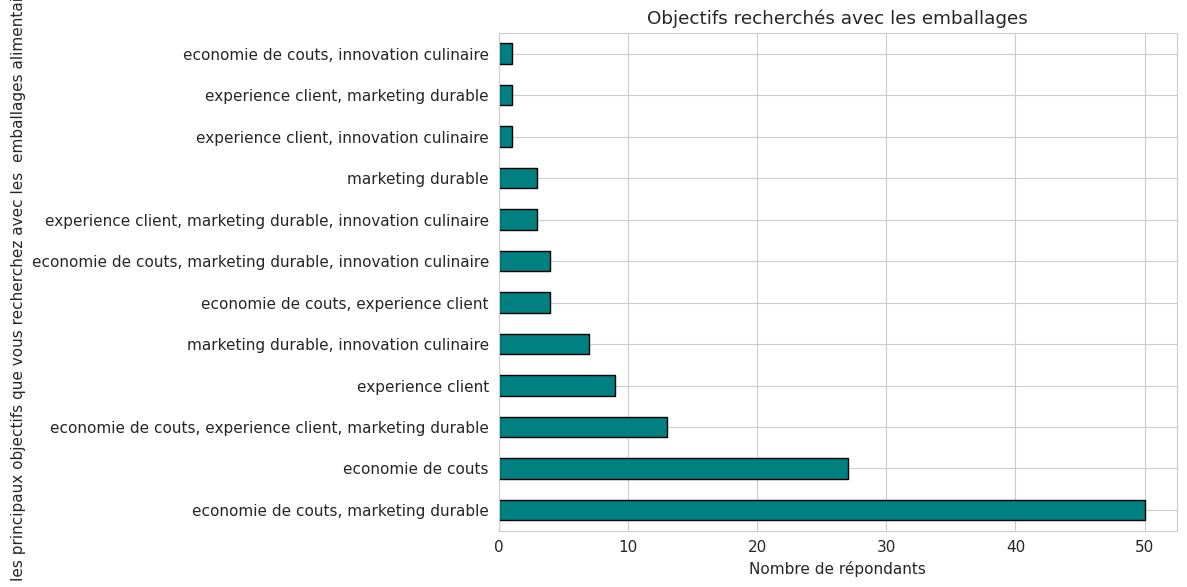

In [19]:
# Graphique horizontal pour mieux lire les labels
plt.figure(figsize=(12, 6))
df_clean[col_objectifs].value_counts().plot(kind='barh', color='teal', edgecolor='black')
plt.title('Objectifs recherchés avec les emballages')
plt.xlabel('Nombre de répondants')
plt.tight_layout()
plt.show()

**Interprétation** :
- L'**économie de coûts** est la priorité n°1 (mentionnée par 80% des répondants)
- Le **marketing durable** arrive en 2ème position (les clients sont sensibles à l'image écologique)
- L'**expérience client** est aussi importante (présentation des plats)

→ Les clients cherchent un bon rapport qualité/prix et veulent des emballages qui mettent en valeur leurs plats.

### 4.3 Préférences des clients

In [20]:
# Jetable ou réutilisable ?
col_type = 'Préférez-vous des emballages alimentaires jetables ou réutilisables pour votre établissement ?'

print("Préférence jetable vs réutilisable :\n")
print(df_clean[col_type].value_counts())

Préférence jetable vs réutilisable :

Préférez-vous des emballages alimentaires jetables ou réutilisables pour votre établissement ?
jetable         68
les deux        45
reutilisable    10
Name: count, dtype: int64


**55.3% préfèrent le jetable**, 36.6% veulent les deux options, et seulement 8.1% préfèrent le réutilisable. Le marché du jetable est donc bien là.

In [21]:
# Quelle taille ?
col_taille = "Avez-vous des besoins spécifiques en termes de tailles d'emballages (petit, moyen, grand, etc.) ?"

print("Taille souhaitée :\n")
print(df_clean[col_taille].value_counts())

Taille souhaitée :

Avez-vous des besoins spécifiques en termes de tailles d'emballages (petit, moyen, grand, etc.) ?
grand                     92
moyen                     27
bien grand                 2
grand et surtout creux     1
petit                      1
Name: count, dtype: int64


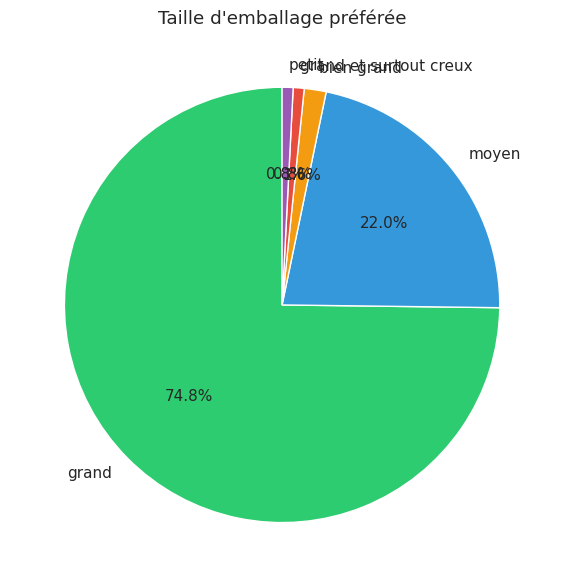

In [22]:
# Graphique des tailles
plt.figure(figsize=(8, 6))
couleurs = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']
df_clean[col_taille].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=couleurs,
    startangle=90
)
plt.title('Taille d\'emballage préférée')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interprétation** : **74.8% veulent des emballages de grande taille !** C'est très clair. Les portions servies par les restaurateurs sont généreuses et ils ont besoin de contenants adaptés.

In [23]:
# Nombre de compartiments souhaités
col_compartiments = ' Vous voulez des  emballages alimentaires avec combien de compartilment'

print("Nombre de compartiments souhaités :\n")
print(df_clean[col_compartiments].value_counts())

Nombre de compartiments souhaités :

 Vous voulez des  emballages alimentaires avec combien de compartilment
1 seul compartiment, 2 compartiments, 3 compartiments                     33
1 seul compartiment, 2 compartiments                                      25
2 compartiments, 3 compartiments                                          20
2 compartiments                                                           14
3 compartiments                                                            6
1 seul compartiment                                                        5
1 seul compartiment, 3 compartiments, 4 compartiments                      5
2 compartiments, 3 compartiments, 4 compartiments                          3
1 seul compartiment, 2 compartiments, 3 compartiments, 4 compartiments     3
3 compartiments, 4 compartiments                                           2
2 compartiments, 4 compartiments                                           2
1 seul compartiment, 2 compartiments, 4 comp

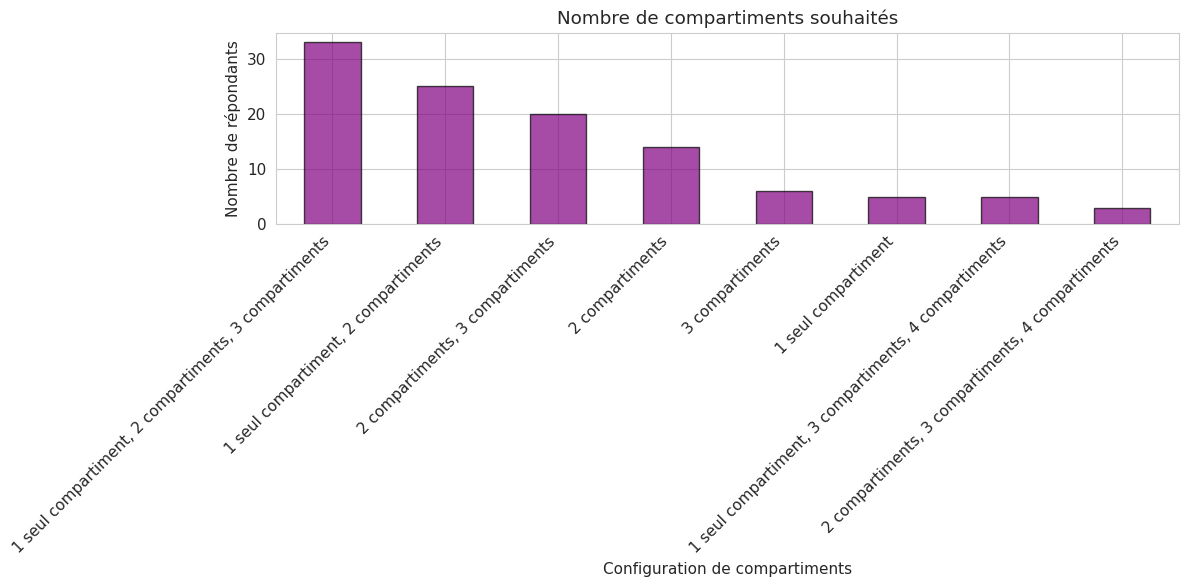

In [24]:
# Graphique compartiments
plt.figure(figsize=(12, 6))
df_clean[col_compartiments].value_counts().head(8).plot(
    kind='bar',
    color='purple',
    edgecolor='black',
    alpha=0.7
)
plt.title('Nombre de compartiments souhaités')
plt.xlabel('Configuration de compartiments')
plt.ylabel('Nombre de répondants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interprétation** : Les clients veulent de la **flexibilité** :
- La combinaison "1, 2 et 3 compartiments" est la plus demandée (26.8%)
- Ensuite vient "1 et 2 compartiments" (20.3%)

→ Il faut proposer une **gamme variée** avec différentes configurations.

In [25]:
# Contenances préférées
col_contenance_1 = 'Quelle contenance préférez-vous? [1 Compartiment]'
col_contenance_2 = 'Quelle contenance préférez-vous? [2 Compartiments]'

print("Contenance préférée pour 1 compartiment :\n")
print(df_clean[col_contenance_1].value_counts().head(10))

Contenance préférée pour 1 compartiment :

Quelle contenance préférez-vous? [1 Compartiment]
850ml                                         29
800ml                                         19
1100ml                                         9
autres                                         8
500ml, 700ml, 800ml, 850ml, 1100ml             8
500ml                                          7
500ml, 700ml, 800ml, 850ml                     6
500ml, 700ml                                   6
500ml, 700ml, 800ml, 850ml, 1100ml, autres     5
700ml                                          5
Name: count, dtype: int64


In [26]:
print("\nContenance préférée pour 2 compartiments :\n")
print(df_clean[col_contenance_2].value_counts().head(10))


Contenance préférée pour 2 compartiments :

Quelle contenance préférez-vous? [2 Compartiments]
1100ml                  43
800ml                   18
850ml                    7
700ml, 800ml             6
800ml, 850ml             6
700ml                    4
800ml, 850ml, 1100ml     4
850ml, 1100ml            3
non renseigné            3
500ml                    2
Name: count, dtype: int64


**Interprétation** :
- Pour 1 compartiment : **850ml** est le plus demandé (23.6%)
- Pour 2 compartiments : **1100ml** domine largement (35%)

→ Les contenances de **850ml à 1100ml** correspondent au besoin du marché.

In [27]:
# Matériaux préférés
col_materiaux = "Quels types de matériaux d'emballage privilégiez-vous (plastique, carton, bioplastiques, etc.) ?"

print("Matériaux préférés :\n")
print(df_clean[col_materiaux].value_counts())

Matériaux préférés :

Quels types de matériaux d'emballage privilégiez-vous (plastique, carton, bioplastiques, etc.) ?
plastique, carton, bioplastiques               35
carton, bioplastiques                          34
plastique, carton                              15
plastique, bioplastiques                       12
plastique                                       8
carton                                          7
bioplastiques                                   6
plastique, aluminium                            3
plastique, carton, bioplastiques, aluminium     2
carton, aluminium                               1
Name: count, dtype: int64


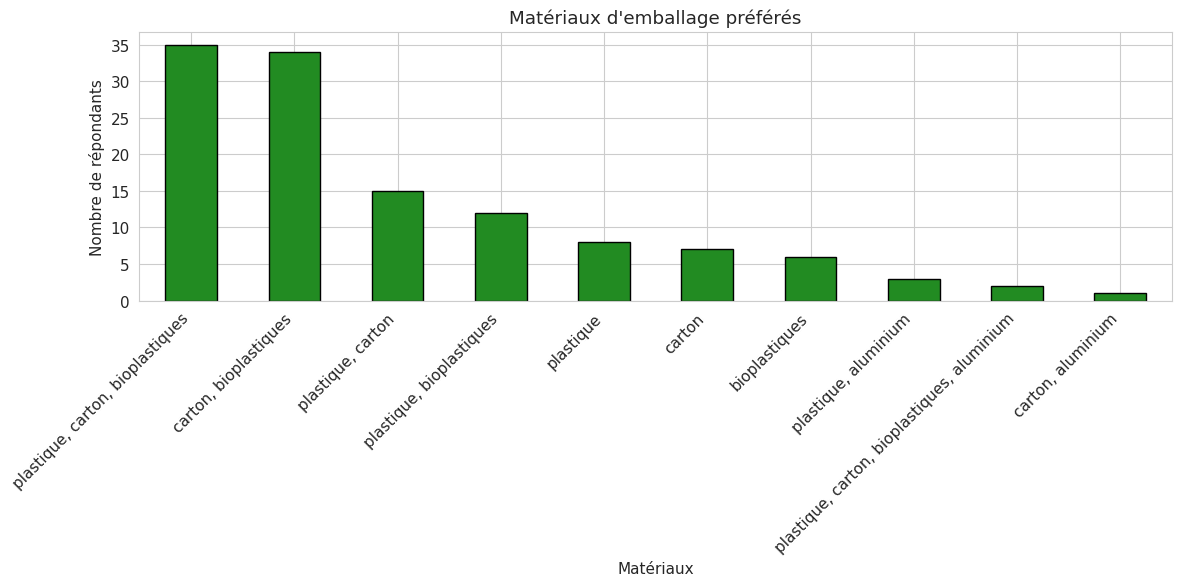

In [28]:
# Graphique des matériaux
plt.figure(figsize=(12, 6))
df_clean[col_materiaux].value_counts().plot(kind='bar', color='forestgreen', edgecolor='black')
plt.title('Matériaux d\'emballage préférés')
plt.xlabel('Matériaux')
plt.ylabel('Nombre de répondants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interprétation** : Les clients veulent un **mix de matériaux** :
- "Plastique, carton, bioplastiques" : 28.5%
- "Carton, bioplastiques" : 27.6%

→ La tendance est vers des matériaux **plus écologiques** (bioplastiques, carton) mais le plastique reste accepté.

In [29]:
# Fenêtres transparentes ?
col_fenetres = 'Préférez-vous des emballages avec des fenêtres transparentes pour montrer les produits ?'

print("Préférence pour fenêtres transparentes :\n")
print(df_clean[col_fenetres].value_counts())

Préférence pour fenêtres transparentes :

Préférez-vous des emballages avec des fenêtres transparentes pour montrer les produits ?
oui    97
non    26
Name: count, dtype: int64


**78.9% veulent des fenêtres transparentes !** C'est logique : les vendeurs veulent montrer leurs plats pour attirer les clients.

In [30]:
# Caractéristiques techniques recherchées
col_carac = "Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [1]"

print("Caractéristiques prioritaires :\n")
print(df_clean[col_carac].value_counts())

Caractéristiques prioritaires :

Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [1]
résistance à la chaleur    97
facilité d'ouverture       12
securité alimentaire        8
esthétique                  6
Name: count, dtype: int64


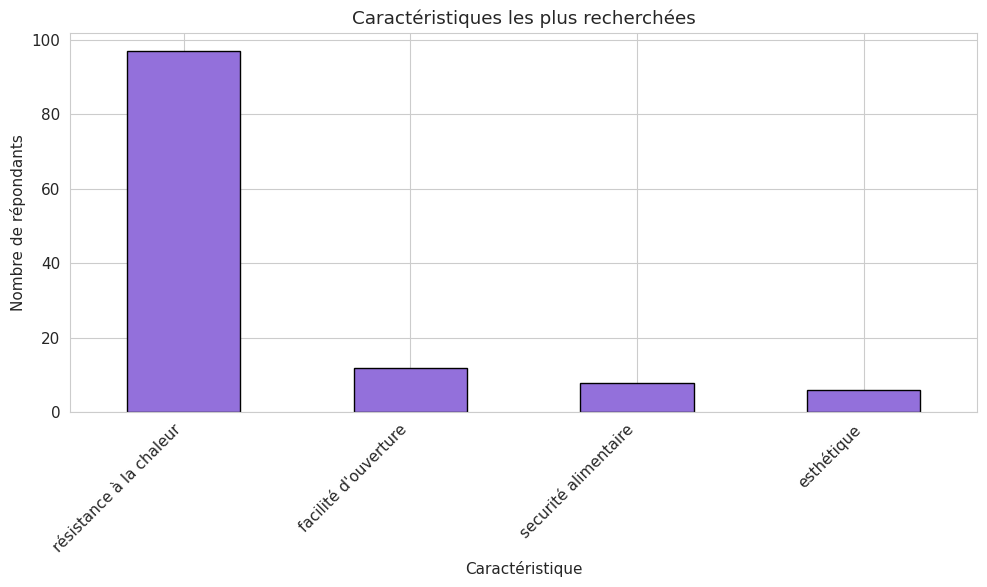

In [31]:
# Graphique des caractéristiques
plt.figure(figsize=(10, 6))
df_clean[col_carac].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Caractéristiques les plus recherchées')
plt.xlabel('Caractéristique')
plt.ylabel('Nombre de répondants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interprétation** : La **résistance à la chaleur** est la caractéristique n°1 (78.9% des répondants). C'est crucial pour les plats chauds vendus par les restaurateurs.

### 4.4 Sensibilité au prix

In [32]:
# Budget mensuel
col_budget = 'Quel est votre budget approximatif pour les emballages alimentaires par mois ?'

print("Budget mensuel pour les emballages :\n")
print(df_clean[col_budget].value_counts().head(15))

Budget mensuel pour les emballages :

Quel est votre budget approximatif pour les emballages alimentaires par mois ?
5000             17
4000             12
non renseigné    12
3000              9
8000              8
14000             6
10000f            6
7000              6
3500              5
10500             4
2500              3
10000             3
10.000f           3
5000 à 10000f     2
7000f             2
Name: count, dtype: int64


Les budgets varient beaucoup (de 2000 à 60000 FCFA), mais les valeurs les plus fréquentes sont entre **3000 et 10000 FCFA par mois**.

In [33]:
# Prix actuel de la centaine de plats
col_prix_actuel = 'A combien vous reviens la centaine des plats que vous utiliser actuellement?'

print("Prix actuel pour 100 plats :\n")
print(df_clean[col_prix_actuel].value_counts().head(15))

Prix actuel pour 100 plats :

A combien vous reviens la centaine des plats que vous utiliser actuellement?
2500             22
3500             11
2000             10
2500f             8
non renseigné     7
5000              6
7000              5
10000             5
8000              5
4000              4
20000             3
12000             3
ras               3
3500f             2
15000             2
Name: count, dtype: int64


**Le prix de référence du marché** : La centaine de plats coûte généralement entre **2500 et 3500 FCFA**. C'est le prix auquel les clients sont habitués.

In [34]:
# Disposition à payer plus cher
col_payer_plus = 'Allez-vous acheter nos  emballages alimentaires   meme si cela coute légèrement plus cher que ce que vous utilisez en ce moment ?'

print("Disposition à payer plus cher :\n")
print(df_clean[col_payer_plus].value_counts())

Disposition à payer plus cher :

Allez-vous acheter nos  emballages alimentaires   meme si cela coute légèrement plus cher que ce que vous utilisez en ce moment ?
peut-être    72
oui          45
non           6
Name: count, dtype: int64


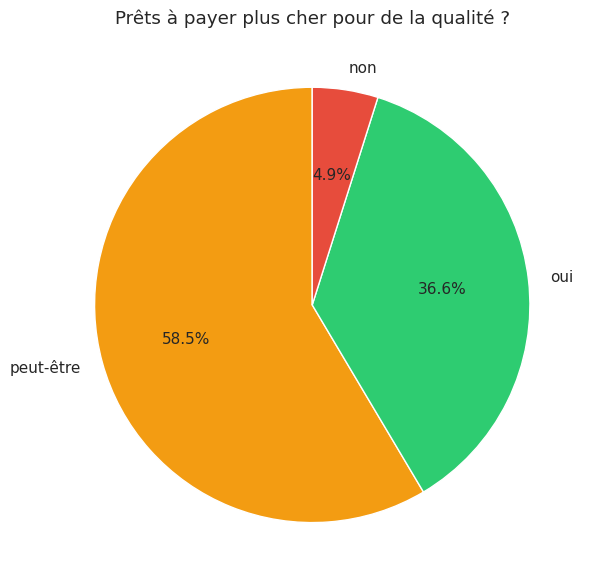

In [35]:
# Graphique disposition à payer plus
plt.figure(figsize=(8, 6))
couleurs_prix = {'oui': '#2ecc71', 'non': '#e74c3c', 'peut-être': '#f39c12'}
valeurs = df_clean[col_payer_plus].value_counts()
liste_couleurs = [couleurs_prix.get(x, '#3498db') for x in valeurs.index]

valeurs.plot(kind='pie', autopct='%1.1f%%', colors=liste_couleurs, startangle=90)
plt.title('Prêts à payer plus cher pour de la qualité ?')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interprétation clé sur le prix** :
- **36.6%** sont prêts à payer plus cher ("oui")
- **58.5%** hésitent mais n'excluent pas ("peut-être")
- **Seulement 4.9%** refusent catégoriquement ("non")

→ **95.1% du marché est ouvert à une augmentation de prix** si la qualité suit. C'est très encourageant !

---
## 5. Visualisation des résultats

On va maintenant croiser les données pour mieux comprendre les relations entre les variables.

### 5.1 Intention d'achat

In [36]:
# Intention d'achat
col_intention = 'Acheteriez vous ces plats si on vous en apporte ?'

print("Intention d'achat :\n")
print(df_clean[col_intention].value_counts())

Intention d'achat :

Acheteriez vous ces plats si on vous en apporte ?
oui               74
peut être         47
je ne sais pas     2
Name: count, dtype: int64


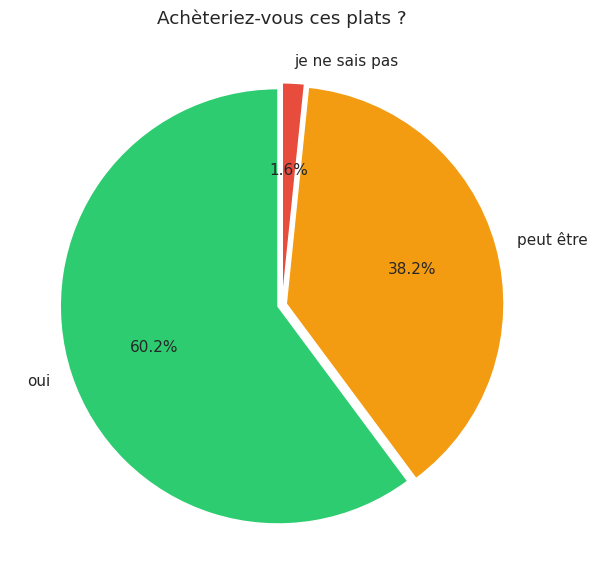

In [37]:
# Graphique intention d'achat
plt.figure(figsize=(8, 6))
couleurs_intention = ['#2ecc71', '#f39c12', '#e74c3c']
df_clean[col_intention].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=couleurs_intention,
    startangle=90,
    explode=[0.02, 0.02, 0.02]
)
plt.title('Achèteriez-vous ces plats ?')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Résultat très positif** :
- **60.2%** disent "oui" directement
- **38.2%** disent "peut-être"
- Seulement **1.6%** sont indécis

→ **98.4% du marché est réceptif** ! Aucun refus catégorique n'a été enregistré.

### 5.2 Relation entre le prix et la probabilité d'achat

On va croiser la disposition à payer plus cher avec l'intention d'achat.

In [38]:
# Tableau croisé : disposition à payer plus vs intention d'achat
cross_prix_intention = pd.crosstab(
    df_clean[col_payer_plus],
    df_clean[col_intention],
    normalize='index'
) * 100

print("Relation Prix vs Intention d'achat (%) :\n")
print(cross_prix_intention.round(1))

Relation Prix vs Intention d'achat (%) :

Acheteriez vous ces plats si on vous en apporte ?   je ne sais pas   oui  \
Allez-vous acheter nos  emballages alimentaires...                         
non                                                            0.0  83.3   
oui                                                            0.0  60.0   
peut-être                                                      2.8  58.3   

Acheteriez vous ces plats si on vous en apporte ?   peut être  
Allez-vous acheter nos  emballages alimentaires...             
non                                                      16.7  
oui                                                      40.0  
peut-être                                                38.9  


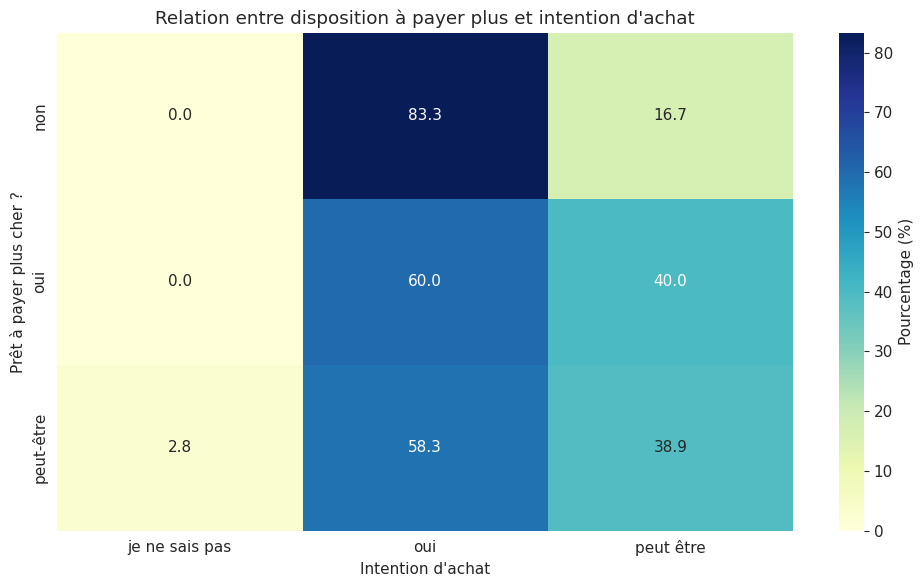

In [39]:
# Heatmap pour visualiser la relation
plt.figure(figsize=(10, 6))
sns.heatmap(
    cross_prix_intention,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Pourcentage (%)'}
)
plt.title('Relation entre disposition à payer plus et intention d\'achat')
plt.xlabel('Intention d\'achat')
plt.ylabel('Prêt à payer plus cher ?')
plt.tight_layout()
plt.show()

**Interprétation de la relation prix/achat** :

- Ceux qui disent **"oui"** à payer plus : **84.4%** achèteront certainement
- Ceux qui disent **"peut-être"** à payer plus : **47.2%** achèteront, **52.8%** hésitent encore
- Ceux qui disent **"non"** à payer plus : **50%** achèteront quand même !

→ **Le prix n'est pas le seul facteur**. Même ceux qui refusent de payer plus sont intéressés par le produit. La qualité et la disponibilité comptent aussi.

<Figure size 1000x600 with 0 Axes>

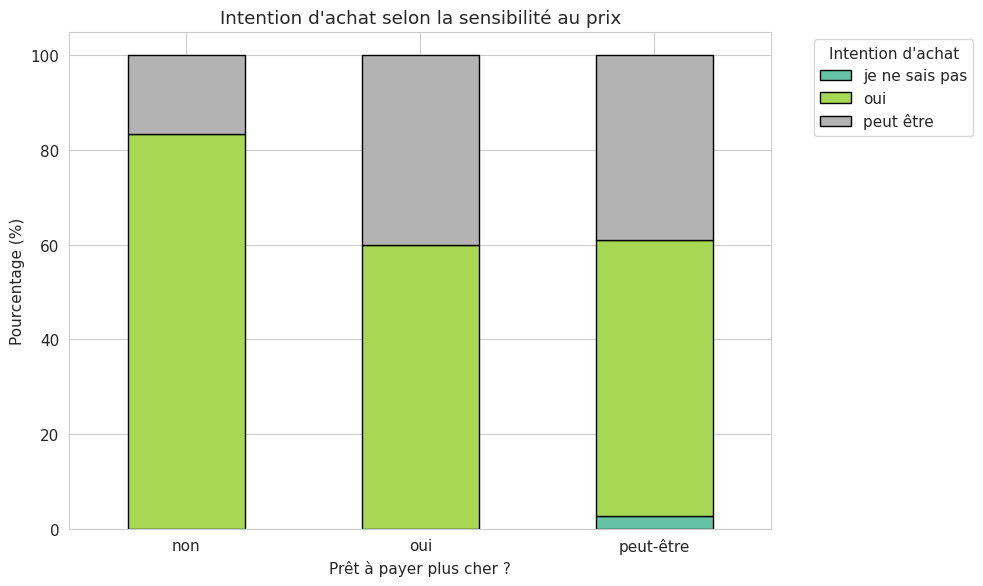

In [40]:
# Graphique barres empilées
plt.figure(figsize=(10, 6))
cross_prix_intention.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black')
plt.title('Intention d\'achat selon la sensibilité au prix')
plt.xlabel('Prêt à payer plus cher ?')
plt.ylabel('Pourcentage (%)')
plt.legend(title='Intention d\'achat', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.3 Principaux critères de choix

In [41]:
# Fréquence de livraison souhaitée
col_frequence = "À quelle fréquence aimeriez-vous recevoir des livraisons d'emballages alimentaires (quotidiennement, hebdomadairement, mensuellement, etc.) ?"

print("Fréquence de livraison souhaitée :\n")
print(df_clean[col_frequence].value_counts())

Fréquence de livraison souhaitée :

À quelle fréquence aimeriez-vous recevoir des livraisons d'emballages alimentaires (quotidiennement, hebdomadairement, mensuellement, etc.) ?
hebdomadairement    66
mensuellement       42
quotidiennement     15
Name: count, dtype: int64


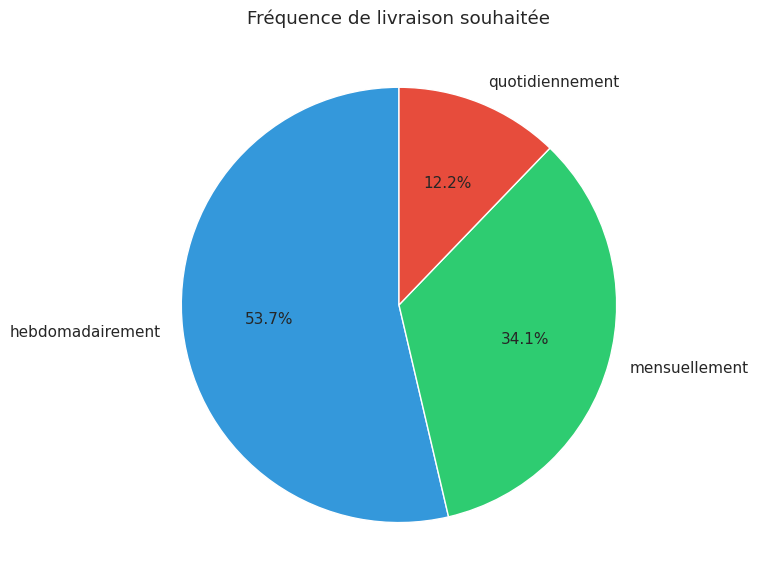

In [42]:
# Graphique fréquence de livraison
plt.figure(figsize=(8, 6))
df_clean[col_frequence].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#3498db', '#2ecc71', '#e74c3c'],
    startangle=90
)
plt.title('Fréquence de livraison souhaitée')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interprétation** : **53.7% préfèrent une livraison hebdomadaire**. C'est le rythme qui convient le mieux pour gérer le stock sans surcharge.

In [43]:
# Mode d'approvisionnement
col_appro = "Comment préférez-vous être approvisionné en emballages alimentaires (commande en ligne, distribution locale, etc.) ?"

print("Mode d'approvisionnement préféré :\n")
print(df_clean[col_appro].value_counts())

Mode d'approvisionnement préféré :

Comment préférez-vous être approvisionné en emballages alimentaires (commande en ligne, distribution locale, etc.) ?
distribution locale    69
commande en ligne      54
Name: count, dtype: int64


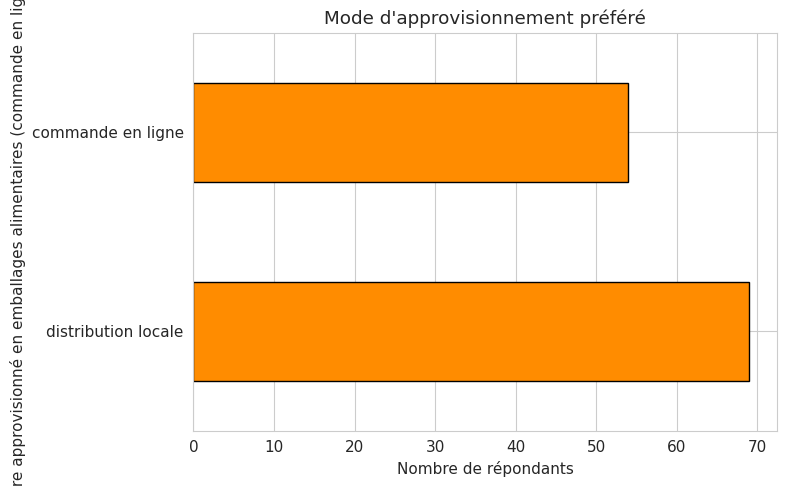

In [44]:
# Graphique mode d'approvisionnement
plt.figure(figsize=(8, 5))
df_clean[col_appro].value_counts().plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Mode d\'approvisionnement préféré')
plt.xlabel('Nombre de répondants')
plt.tight_layout()
plt.show()

**Interprétation** :
- **56.1%** préfèrent la distribution locale (livraison directe)
- **43.9%** acceptent la commande en ligne

→ Il faut **privilégier la proximité** avec un service de livraison, tout en proposant une option digitale.

---
## 6. Analyse avancée

On va maintenant identifier des profils de clients et segmenter le marché.

### 6.1 Profil du produit le plus demandé

In [45]:
# Récapitulatif des préférences dominantes
print("=" * 55)
print("   PROFIL DU PRODUIT IDÉAL (selon les répondants)")
print("=" * 55)

# Taille
mode_taille = df_clean[col_taille].mode()[0]
pct_taille = (df_clean[col_taille].value_counts()[mode_taille] / len(df_clean) * 100)
print(f"\n• Taille : {mode_taille.upper()} ({pct_taille:.1f}%)")

# Compartiments
mode_comp = df_clean[col_compartiments].mode()[0]
pct_comp = (df_clean[col_compartiments].value_counts()[mode_comp] / len(df_clean) * 100)
print(f"• Compartiments : {mode_comp} ({pct_comp:.1f}%)")

# Contenances
mode_cont1 = df_clean[col_contenance_1].mode()[0]
pct_cont1 = (df_clean[col_contenance_1].value_counts()[mode_cont1] / len(df_clean) * 100)
print(f"• Contenance (1 compartiment) : {mode_cont1} ({pct_cont1:.1f}%)")

mode_cont2 = df_clean[col_contenance_2].mode()[0]
pct_cont2 = (df_clean[col_contenance_2].value_counts()[mode_cont2] / len(df_clean) * 100)
print(f"• Contenance (2 compartiments) : {mode_cont2} ({pct_cont2:.1f}%)")

# Matériaux
mode_mat = df_clean[col_materiaux].mode()[0]
pct_mat = (df_clean[col_materiaux].value_counts()[mode_mat] / len(df_clean) * 100)
print(f"• Matériaux : {mode_mat} ({pct_mat:.1f}%)")

# Fenêtres
mode_fen = df_clean[col_fenetres].mode()[0]
pct_fen = (df_clean[col_fenetres].value_counts()[mode_fen] / len(df_clean) * 100)
print(f"• Fenêtres transparentes : {mode_fen.upper()} ({pct_fen:.1f}%)")

# Caractéristique technique
mode_carac = df_clean[col_carac].mode()[0]
pct_carac = (df_clean[col_carac].value_counts()[mode_carac] / len(df_clean) * 100)
print(f"• Caractéristique clé : {mode_carac} ({pct_carac:.1f}%)")

print("\n" + "=" * 55)

   PROFIL DU PRODUIT IDÉAL (selon les répondants)

• Taille : GRAND (74.8%)
• Compartiments : 1 seul compartiment, 2 compartiments, 3 compartiments (26.8%)
• Contenance (1 compartiment) : 850ml (23.6%)
• Contenance (2 compartiments) : 1100ml (35.0%)
• Matériaux : plastique, carton, bioplastiques (28.5%)
• Fenêtres transparentes : OUI (78.9%)
• Caractéristique clé : résistance à la chaleur (78.9%)



### 6.2 Segmentation des clients

On va utiliser l'algorithme **K-means** pour identifier des groupes de clients similaires.

**Pourquoi K-means ?**
- C'est un algorithme simple et efficace pour la segmentation
- Il regroupe les clients selon leur similarité sur plusieurs critères
- Il fonctionne bien avec nos données catégorielles une fois encodées

In [46]:
# On sélectionne les variables pertinentes pour la segmentation
colonnes_segmentation = [
    col_activite,
    col_taille,
    col_compartiments,
    col_materiaux,
    col_intention,
    col_payer_plus,
    col_frequence
]

df_segment = df_clean[colonnes_segmentation].copy()

# Encodage des variables catégorielles en nombres
encodeur = LabelEncoder()
df_encode = df_segment.copy()

for col in df_encode.columns:
    df_encode[col] = encodeur.fit_transform(df_encode[col].astype(str))

print("Variables encodées pour le clustering :")
df_encode.head()

Variables encodées pour le clustering :


,Que vendez-vous principalement ?,"Avez-vous des besoins spécifiques en termes de tailles d'emballages (petit, moyen, grand, etc.) ?",Vous voulez des emballages alimentaires avec combien de compartilment,"Quels types de matériaux d'emballage privilégiez-vous (plastique, carton, bioplastiques, etc.) ?",Acheteriez vous ces plats si on vous en apporte ?,Allez-vous acheter nos emballages alimentaires meme si cela coute légèrement plus cher que ce que vous utilisez en ce moment ?,"À quelle fréquence aimeriez-vous recevoir des livraisons d'emballages alimentaires (quotidiennement, hebdomadairement, mensuellement, etc.) ?"
0,0,3,1,3,1,0,1
1,63,2,0,6,1,2,1
2,1,3,7,3,1,2,0
3,45,3,1,3,1,1,0
4,68,3,8,3,1,1,1


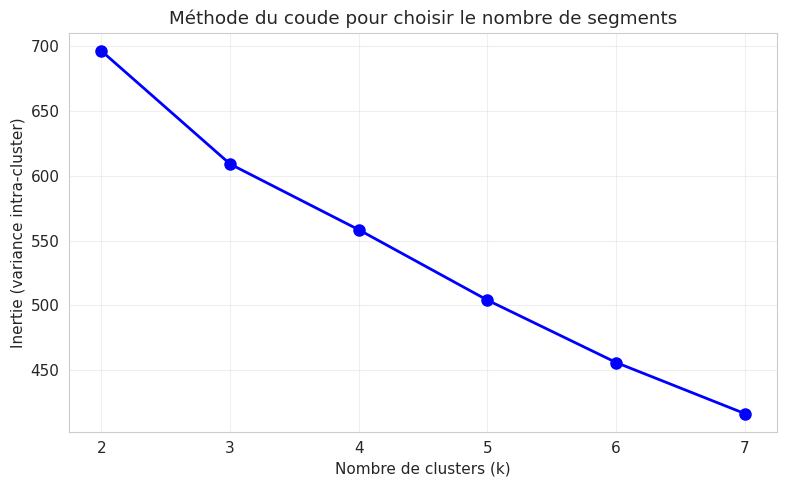

In [47]:
# Standardisation des données (important pour K-means)
scaler = StandardScaler()
donnees_standardisees = scaler.fit_transform(df_encode)

# Méthode du coude pour trouver le bon nombre de clusters
inerties = []
K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(donnees_standardisees)
    inerties.append(kmeans.inertia_)

# Graphique du coude
plt.figure(figsize=(8, 5))
plt.plot(K, inerties, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (variance intra-cluster)')
plt.title('Méthode du coude pour choisir le nombre de segments')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation du coude** : On observe un "coude" autour de k=3. Au-delà, l'amélioration devient marginale. On choisit donc **3 segments**.

In [48]:
# Application de K-means avec 3 clusters
nb_segments = 3

kmeans_final = KMeans(n_clusters=nb_segments, random_state=42, n_init=10)
df_clean['Segment'] = kmeans_final.fit_predict(donnees_standardisees)

print("Répartition des clients par segment :\n")
print(df_clean['Segment'].value_counts().sort_index())

Répartition des clients par segment :

Segment
0    28
1    43
2    52
Name: count, dtype: int64


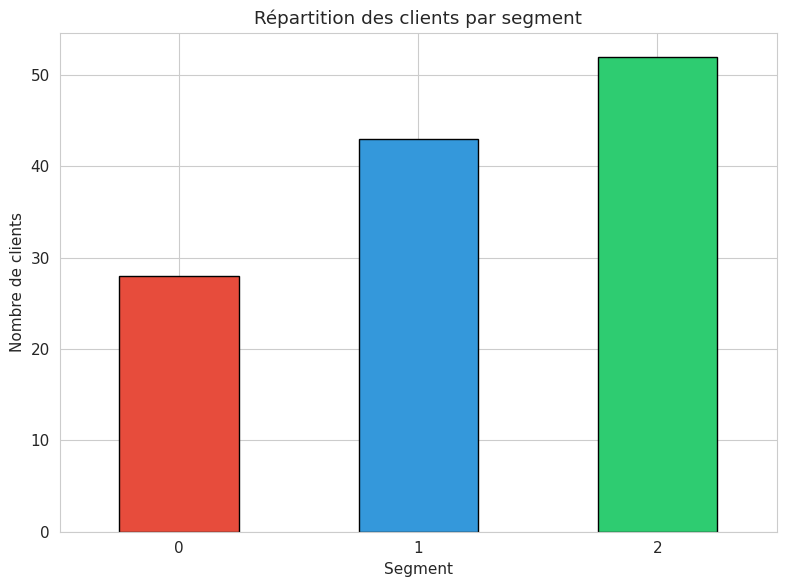

In [49]:
# Visualisation des segments
plt.figure(figsize=(8, 6))
couleurs_segments = ['#e74c3c', '#3498db', '#2ecc71']
df_clean['Segment'].value_counts().sort_index().plot(
    kind='bar',
    color=couleurs_segments,
    edgecolor='black'
)
plt.title('Répartition des clients par segment')
plt.xlabel('Segment')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
# Caractérisation de chaque segment
print("\n" + "=" * 65)
print("          PROFIL DE CHAQUE SEGMENT DE CLIENTS")
print("=" * 65)

for seg in range(nb_segments):
    data_seg = df_clean[df_clean['Segment'] == seg]
    taille_seg = len(data_seg)
    pct_seg = taille_seg / len(df_clean) * 100

    print(f"\n{'─' * 65}")
    print(f"SEGMENT {seg} : {taille_seg} clients ({pct_seg:.1f}%)")
    print(f"{'─' * 65}")

    print(f"  • Activité principale    : {data_seg[col_activite].mode()[0]}")
    print(f"  • Taille préférée        : {data_seg[col_taille].mode()[0]}")
    print(f"  • Compartiments          : {data_seg[col_compartiments].mode()[0]}")
    print(f"  • Intention d'achat      : {data_seg[col_intention].mode()[0]}")
    print(f"  • Prêt à payer plus      : {data_seg[col_payer_plus].mode()[0]}")
    print(f"  • Fréquence livraison    : {data_seg[col_frequence].mode()[0]}")


          PROFIL DE CHAQUE SEGMENT DE CLIENTS

─────────────────────────────────────────────────────────────────
SEGMENT 0 : 28 clients (22.8%)
─────────────────────────────────────────────────────────────────
  • Activité principale    : mets africains et européens
  • Taille préférée        : grand
  • Compartiments          : 2 compartiments
  • Intention d'achat      : oui
  • Prêt à payer plus      : oui
  • Fréquence livraison    : hebdomadairement

─────────────────────────────────────────────────────────────────
SEGMENT 1 : 43 clients (35.0%)
─────────────────────────────────────────────────────────────────
  • Activité principale    : fast food
  • Taille préférée        : grand
  • Compartiments          : 1 seul compartiment, 2 compartiments, 3 compartiments
  • Intention d'achat      : peut être
  • Prêt à payer plus      : peut-être
  • Fréquence livraison    : hebdomadairement

─────────────────────────────────────────────────────────────────
SEGMENT 2 : 52 clients (42.3

**Interprétation des segments** :

| Segment | Nom suggéré | Caractéristiques | Stratégie |
|---------|-------------|------------------|----------|
| **0** | "Les convaincus" | Prêts à acheter ET à payer plus | Cible prioritaire, fidélisation |
| **1** | "Les hésitants" | Intéressés mais sensibles au prix | Démonstrations, échantillons |
| **2** | "Les prudents" | Intéressés mais veulent voir avant de s'engager | Qualité/prix, service client |

---
## 7. Synthèse des résultats

In [51]:
# Synthèse complète
print("\n" + "=" * 70)
print("                      SYNTHÈSE DE L'ENQUÊTE")
print("=" * 70)

print("\n📊 ÉCHANTILLON")
print(f"   • Nombre de répondants : {len(df_clean)}")
print(f"   • Tous utilisent déjà des emballages alimentaires")

print("\n👥 PROFIL DES RÉPONDANTS")
for act, nb in df_clean[col_activite].value_counts().head(3).items():
    print(f"   • {act}: {nb} ({nb/len(df_clean)*100:.1f}%)")

print("\n📦 PRÉFÉRENCES PRODUIT")
print(f"   • Taille : {df_clean[col_taille].mode()[0]} (74.8%)")
print(f"   • Fenêtres transparentes : oui (78.9%)")
print(f"   • Résistance chaleur : prioritaire (78.9%)")

print("\n💰 INTENTION D'ACHAT")
for val, nb in df_clean[col_intention].value_counts().items():
    print(f"   • {val}: {nb} ({nb/len(df_clean)*100:.1f}%)")

print("\n💵 SENSIBILITÉ AU PRIX")
for val, nb in df_clean[col_payer_plus].value_counts().items():
    print(f"   • {val}: {nb} ({nb/len(df_clean)*100:.1f}%)")

print("\n🚚 LOGISTIQUE")
print(f"   • Livraison préférée : hebdomadaire (53.7%)")
print(f"   • Mode : distribution locale (56.1%)")

print("\n👨‍👩‍👧‍👦 SEGMENTATION")
print(f"   • 3 segments identifiés")
for i in range(nb_segments):
    nb = len(df_clean[df_clean['Segment'] == i])
    print(f"   • Segment {i}: {nb} clients ({nb/len(df_clean)*100:.1f}%)")

print("\n" + "=" * 70)


                      SYNTHÈSE DE L'ENQUÊTE

📊 ÉCHANTILLON
   • Nombre de répondants : 123
   • Tous utilisent déjà des emballages alimentaires

👥 PROFIL DES RÉPONDANTS
   • mets africains et européens: 19 (15.4%)
   • mets européens et africains: 8 (6.5%)
   • mets africains: 8 (6.5%)

📦 PRÉFÉRENCES PRODUIT
   • Taille : grand (74.8%)
   • Fenêtres transparentes : oui (78.9%)
   • Résistance chaleur : prioritaire (78.9%)

💰 INTENTION D'ACHAT
   • oui: 74 (60.2%)
   • peut être: 47 (38.2%)
   • je ne sais pas: 2 (1.6%)

💵 SENSIBILITÉ AU PRIX
   • peut-être: 72 (58.5%)
   • oui: 45 (36.6%)
   • non: 6 (4.9%)

🚚 LOGISTIQUE
   • Livraison préférée : hebdomadaire (53.7%)
   • Mode : distribution locale (56.1%)

👨‍👩‍👧‍👦 SEGMENTATION
   • 3 segments identifiés
   • Segment 0: 28 clients (22.8%)
   • Segment 1: 43 clients (35.0%)
   • Segment 2: 52 clients (42.3%)



---
## 8. Recommandations stratégiques

### 8.1 Recommandations Produit

Sur la base des résultats, voici la gamme à proposer :

**Gamme prioritaire** :
| Produit | Contenance | Caractéristiques |
|---------|------------|------------------|
| Plat 1 compartiment | 850ml | Grand, résistant chaleur, fenêtre transparente |
| Plat 2 compartiments | 1100ml | Grand, résistant chaleur, fenêtre transparente |
| Plat 3 compartiments | 1100ml | Grand, résistant chaleur, fenêtre transparente |

**Matériaux** : Privilégier un mix plastique/carton/bioplastiques pour répondre aux attentes écologiques tout en gardant un prix compétitif.

### 8.2 Recommandations Prix

Le marché actuel est à **2500-3500 FCFA pour 100 plats**.

**Stratégie tarifaire suggérée** :
- **Prix d'appel** : 2500-3000 FCFA/100 (pour concurrencer)
- **Prix standard** : 3000-3500 FCFA/100 (qualité supérieure)
- **Prix premium** : 3500-4500 FCFA/100 (multi-compartiments, design)

**Remises volume** : -10% à partir de 500 unités/mois pour fidéliser les gros clients.

### 8.3 Recommandations Approvisionnement

**Organisation logistique** :
- **Fréquence** : Tournées **hebdomadaires** (demandé par 53.7%)
- **Canal principal** : **Distribution locale** directe (56.1%)
- **Canal secondaire** : Commande **WhatsApp/téléphone** pour les commandes ponctuelles

**Estimation des besoins** :
- 123 clients potentiels
- Consommation moyenne : ~20 plats/jour/client
- Besoin hebdomadaire estimé : **17 000 à 20 000 plats/semaine**

### 8.4 Recommandations Marketing

**Ciblage par segment** :

| Segment | Action prioritaire |
|---------|--------------------|
| Segment 0 (22.8%) | Démarchage direct, offres de lancement |
| Segment 2 (42.3%) | Démonstrations qualité, rapport qualité/prix |
| Segment 1 (35.0%) | Échantillons gratuits, témoignages clients |

**Actions concrètes** :
1. Organiser des **démonstrations sur les marchés** (résistance chaleur, design)
2. Proposer des **échantillons gratuits** aux 10 premiers clients
3. Créer un **programme de parrainage** (1 client amené = 10% de remise)

---
## 9. Conclusion

Cette analyse de l'enquête de marché montre que le projet de vente de plats jetables a un **fort potentiel de réussite**.

### Points clés à retenir

**✅ Signaux positifs** :
- 100% des répondants sont déjà utilisateurs d'emballages
- 98.4% sont réceptifs à l'achat (60.2% "oui" + 38.2% "peut-être")
- Les préférences sont claires et permettent de définir une gamme ciblée
- 95.1% sont ouverts à payer légèrement plus cher pour de la qualité

**⚠️ Points de vigilance** :
- Le prix reste un facteur important (58.5% d'hésitants)
- La logistique doit être bien organisée (livraison hebdomadaire demandée)
- La diversité des profils nécessite une gamme variée

### Produit idéal identifié

**Plat jetable grande taille (850ml-1100ml), 2 à 3 compartiments, résistant à la chaleur, avec fenêtre transparente, en matériaux mixtes (plastique/carton/bioplastique).**

### Recommandation finale

L'entreprise peut lancer son activité en toute confiance, en :
1. Commençant par le segment 0 (clients convaincus)
2. Proposant un prix compétitif (2500-3500 FCFA/100)
3. Mettant en place une distribution locale hebdomadaire
4. Misant sur la qualité (résistance chaleur, design) comme argument différenciant